
Welcome to Population Genetics Simulations.
Thank you for downloading!



c:\PGS-Population_Genetics_Simulations\src\PGS\ado_model_02.py:127: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('NA', numpy.nan)
c:\PGS-Population_Genetics_Simulations\src\PGS\ado_model_02.py:127: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('NA', numpy.nan)
c:\PGS-Population_Genetics_Simulations\src\PGS\ado_model_02.py:127: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. 

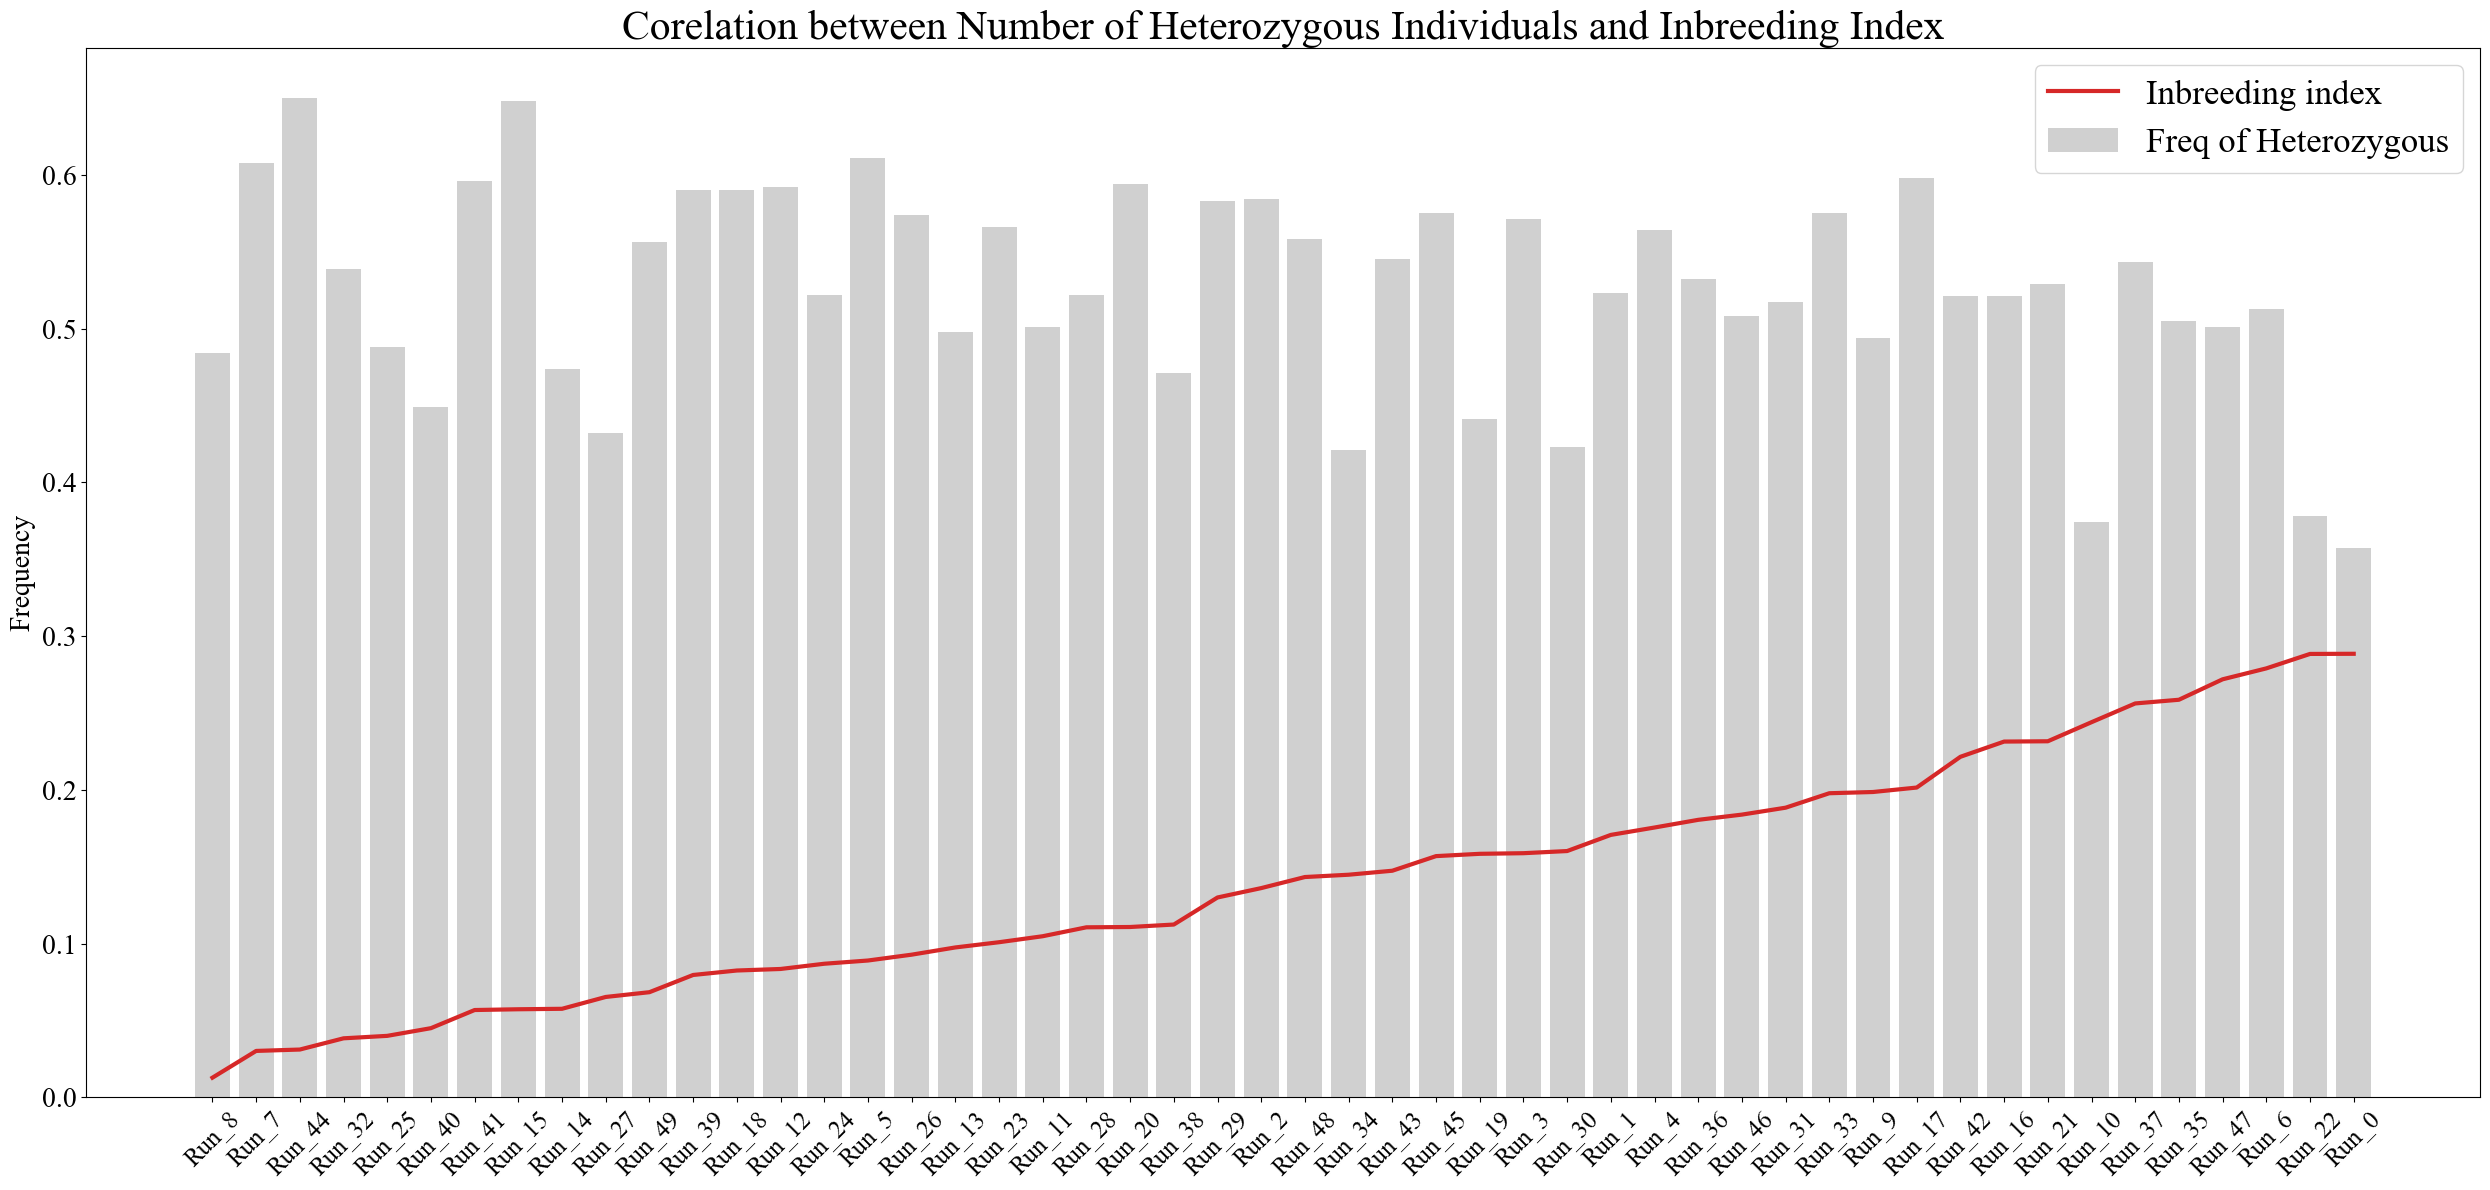

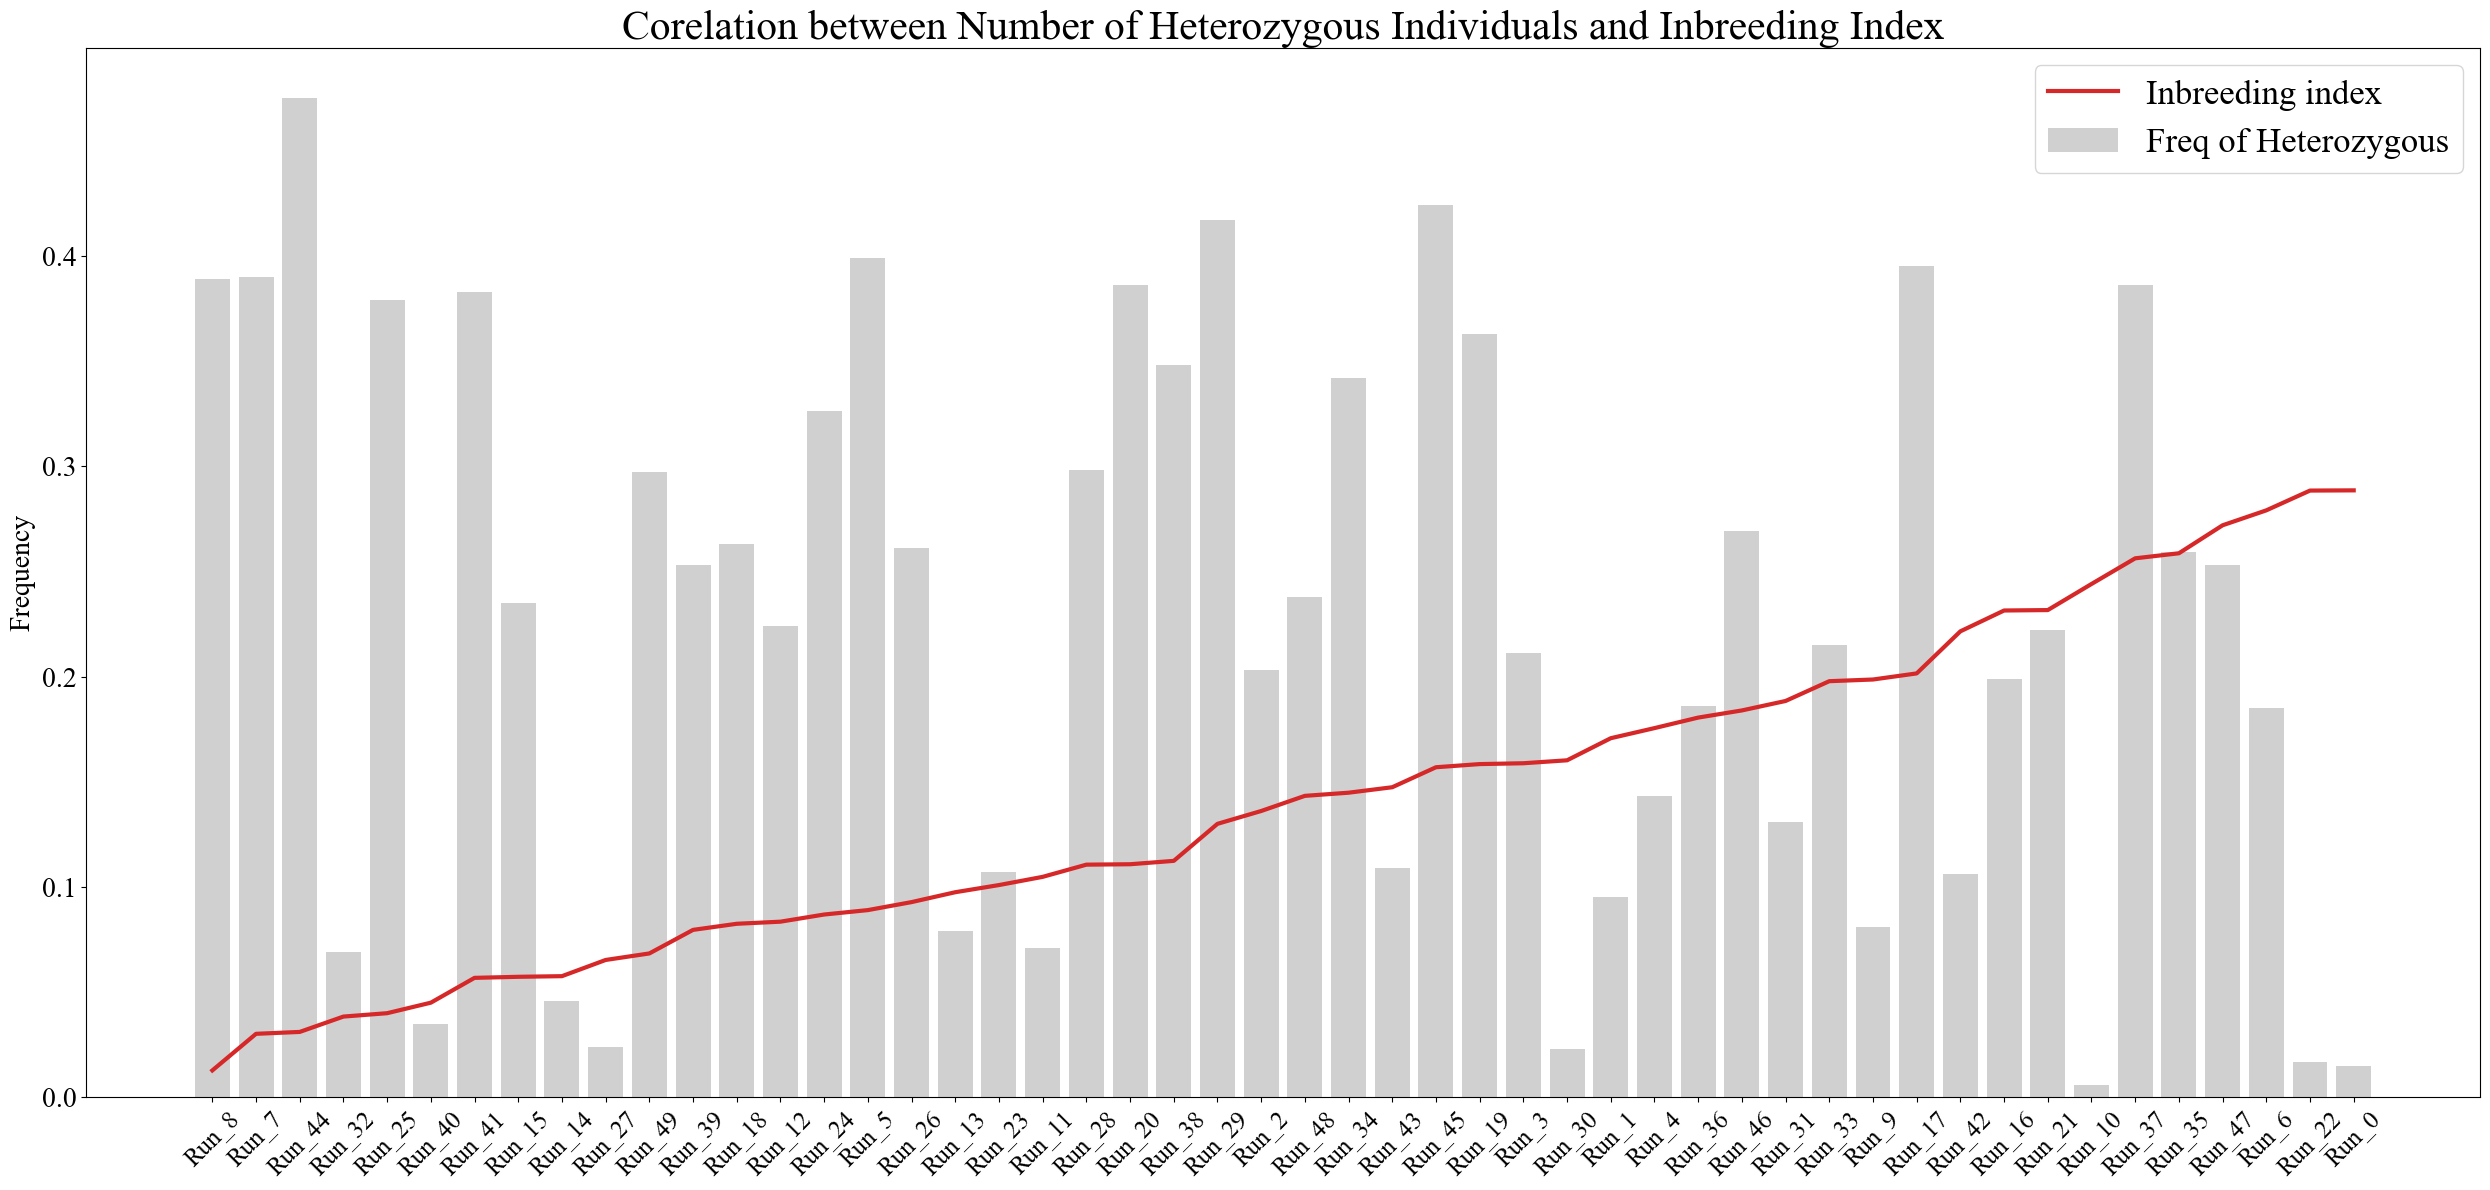

In [ ]:
import random
from PGS import create_parents, mating_matrix_random, calc_stats, ado_model_multiple, visualization_multiple

# Step 1: Establish global variables

mate_type = 'mixed'
output_file = 'inbr'
num_locus = 1

# Step 2: Create a loop for multiple populations
i = 0
while i < 50: # number of populations

    # Step 3: Generate a random inbreeding index for this population
    
    inbr_indx = round(random.uniform(0.01, 0.3), 4)

    # Step 4: Create parent data

    df, num_alleles, allele_probabilities = create_parents(
        num_locus=num_locus,
        num_alleles=3,
        num_individuals=1000,
        major_af=0.3,
        output_path=output_file
    )

    # Step 5: Create offspring data

    offspring_df, inbr_idx = mating_matrix_random(
        df=df,
        mating_type=mate_type,
        num_offsprings=1000,
        inbreeding_index=inbr_indx,
        output_path=output_file
    )

    # Step 6: Calculate genotype frequencies for every population

    calc_stats(
        df=df,
        offspring_df=offspring_df,
        mating_type=mate_type,
        num_locus=num_locus,
        allele_probability=allele_probabilities,
        inbreeding_index=inbr_indx,
        output_path=output_file
    )

    # Step 7: Simulate allelic dropout

    df_expected, df_observed = ado_model_multiple(
        input_path=output_file,
        mating_type=mate_type,
        output_paht=output_file
    )

    i+=1

# Step 8: Visualize heterozygosity frequencies

visualization_multiple(df_expected)
visualization_multiple(df_observed)